In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from google.colab import files
uploaded=files.upload()

Saving abalone (1).csv to abalone (1).csv


In [3]:
df = pd.read_csv("abalone (1).csv")
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
# Add column names manually (from abalone.names file)
df.columns = [
    "Sex", "Length", "Diameter", "Height",
    "WholeWeight", "ShuckedWeight", "VisceraWeight",
    "ShellWeight", "Rings"
]

# print(df.head())


In [ ]:
df

<Axes: >

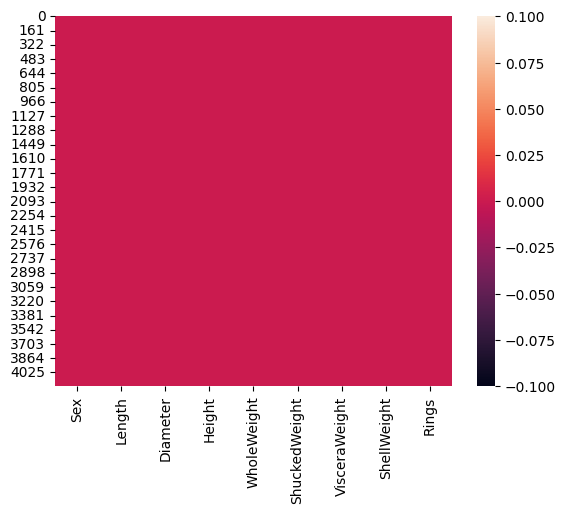

In [5]:
import seaborn as sns
sns.heatmap(df.isnull())


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sex            4177 non-null   object 
 1   Length         4177 non-null   float64
 2   Diameter       4177 non-null   float64
 3   Height         4177 non-null   float64
 4   WholeWeight    4177 non-null   float64
 5   ShuckedWeight  4177 non-null   float64
 6   VisceraWeight  4177 non-null   float64
 7   ShellWeight    4177 non-null   float64
 8   Rings          4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [8]:
df.describe()

,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [ ]:
# sns.heatmap(df.isnull(), cbar = False, cmap = 'c')

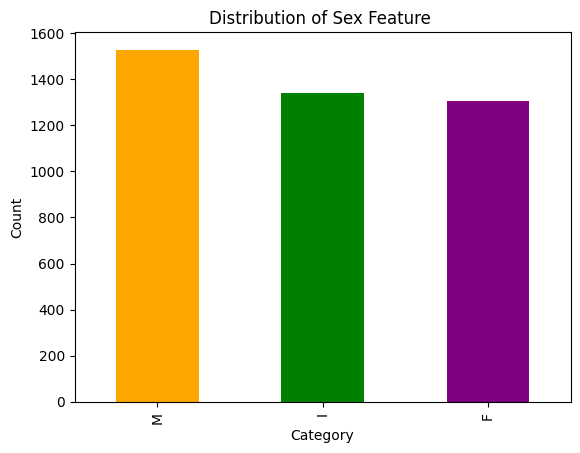

In [9]:
df['Sex'].value_counts().plot(kind = 'bar',color = ['orange','green','purple'])
plt.title("Distribution of Sex Feature ")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

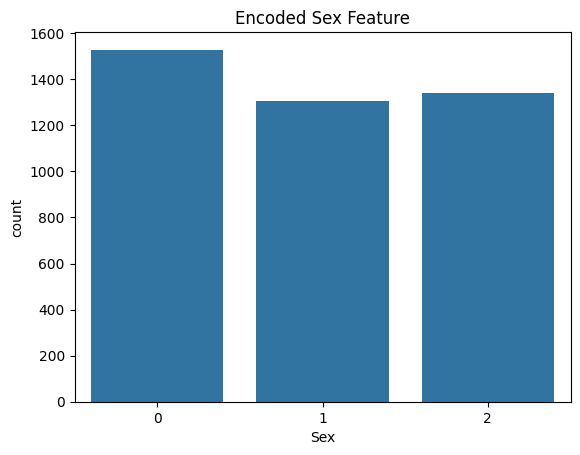

In [10]:
df['Sex'] = df['Sex'].map({"M":0, "F" :1,"I":2})
sns.countplot(x = "Sex", data = df)
plt.title("Encoded Sex Feature")
plt.show()

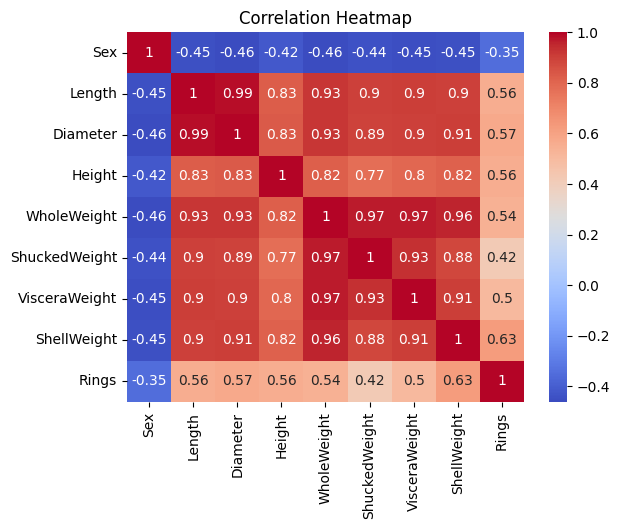

In [11]:
corr = df.corr()
sns.heatmap(corr,annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

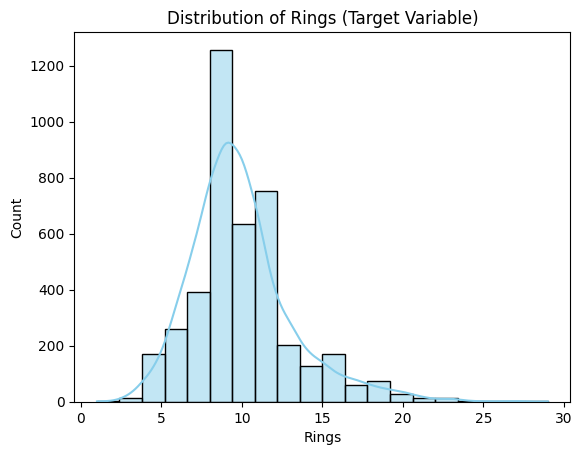

In [12]:
sns.histplot(df['Rings'],bins = 20, kde = True, color = 'skyblue')
plt.title("Distribution of Rings (Target Variable)")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
x = df.drop("Rings", axis =1)
y = df["Rings"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=32)
x_test

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
1729,0,0.665,0.525,0.175,1.4430,0.6635,0.3845,0.3530
1206,1,0.750,0.570,0.210,2.2360,1.1090,0.5195,0.5450
1778,1,0.490,0.355,0.160,0.8795,0.3485,0.2150,0.2825
2451,0,0.350,0.260,0.090,0.1980,0.0725,0.0560,0.0600
390,2,0.415,0.325,0.100,0.3215,0.1535,0.0595,0.1050
...,...,...,...,...,...,...,...,...
3061,0,0.630,0.495,0.180,1.3100,0.4950,0.2950,0.4695
311,0,0.560,0.440,0.140,0.9710,0.4430,0.2045,0.2650
47,1,0.460,0.375,0.120,0.4605,0.1775,0.1100,0.1500
4092,1,0.625,0.490,0.190,1.7015,0.7465,0.4105,0.3855


In [14]:
y_test

,Rings
1729,11
1206,11
1778,8
2451,10
390,10
...,...
3061,10
311,14
47,7
4092,11


In [15]:
y_train

,Rings
2870,7
2244,11
1348,9
1523,12
3047,9
...,...
4030,7
2940,10
1334,10
1579,8


In [16]:
x_train

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
2870,2,0.370,0.270,0.090,0.1855,0.0700,0.0425,0.0650
2244,2,0.355,0.280,0.100,0.2275,0.0935,0.0455,0.0850
1348,0,0.590,0.470,0.180,1.1870,0.5985,0.2270,0.3100
1523,0,0.690,0.525,0.200,1.7825,0.9165,0.3325,0.4610
3047,0,0.590,0.435,0.165,0.9765,0.4525,0.2395,0.2350
...,...,...,...,...,...,...,...,...
4030,2,0.435,0.325,0.100,0.3660,0.1740,0.0725,0.1090
2940,0,0.625,0.490,0.120,0.8765,0.4560,0.1800,0.2330
1334,1,0.575,0.420,0.135,0.8570,0.4610,0.1470,0.2125
1579,2,0.495,0.400,0.105,0.6020,0.2505,0.1265,0.1900
